# Task 2 — Explanation: Chân dung khách hàng mua MANU policy

**Mục tiêu (theo đề):** giải thích *vì sao* khách hàng sở hữu MANU policy — **đặc điểm & chân dung** của họ, trình bày sao cho **dễ hiểu · hữu ích · hành động được** để hỗ trợ quản lý làm chiến dịch bán hàng.

> Đây là phần **giải thích nghiệp vụ**, không chấm theo độ chính xác mô hình. Nguyên liệu (IV/SHAP) lấy từ mô hình LightGBM ở Task 1; ở đây ta *dịch* chúng sang ngôn ngữ kinh doanh và bổ sung phân khúc + khuyến nghị.

**Bố cục:** (1) chuẩn bị & từ điển tên → (2) chân dung: người mua vs toàn dân → (3) phân khúc & độ đa dạng → (4) vì sao họ mua (IV) → (5) segment ưu tiên cho chiến dịch → (6) khuyến nghị → (7) giới hạn.

## 1 · Chuẩn bị dữ liệu & từ điển tên (theo `attributes_description.pdf`)

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)

df = pd.read_csv('Data/train_data.txt', sep=',')
TARGET = '86'
N = len(df); BUY = int(df[TARGET].sum()); BASE = df[TARGET].mean()
print(f'Tong KH: {N} | Nguoi mua: {BUY} | Ti le nen (base rate): {BASE*100:.2f}%')

# Ten 10 phan khuc khach hang (cot 5 - Customer main type, Appendix A2)
MAIN = {1:'Successful hedonists', 2:'Driven Growers', 3:'Average Family', 4:'Career Loners',
        5:'Living well', 6:'Cruising Seniors', 7:'Retired & Religious', 8:'Family with grown ups',
        9:'Conservative families', 10:'Farmers'}
# Cac cap cot san pham quan trong (Contribution 44-64 / Number 65-85)
PROD = {'47':'BH O to', '59':'BH Chay', '55':'BH Life', '63':'BH Property', '44':'Third-party private'}
NUM_COLS = [str(i) for i in range(65, 86)]            # so luong HD moi loai
df['n_types'] = (df[NUM_COLS] > 0).sum(axis=1)        # so LOAI bao hiem dang so huu
buy = df[df[TARGET] == 1]

Tong KH: 5822 | Nguoi mua: 348 | Ti le nen (base rate): 5.98%


## 2 · Chân dung: người mua vs toàn dân

So sánh tỉ lệ khách có mỗi đặc điểm giữa **nhóm người mua** và **toàn bộ dân số**. Cột `boi_so` = người mua gấp bao nhiêu lần toàn dân → càng cao càng đặc trưng.

In [2]:
def profile(name, cond):
    pa = cond.mean()*100
    pb = cond[df[TARGET]==1].mean()*100
    return {'dac_diem':name, 'nguoi_mua_%':round(pb,1), 'toan_dan_%':round(pa,1),
            'boi_so':round(pb/pa,2) if pa>0 else np.nan}

rows = [
    profile('So huu >=3 loai BH',        df['n_types']>=3),
    profile('Phan khuc Growers/Hedonist',df['5'].isin([1,2])),
    profile('Khu vuc suc mua cao (>=6)', df['43']>=6),
    profile('Da co BH O to',             df['47']>0),
    profile('Thu nhap khu vuc cao (>=6)',df['42']>=6),
    profile('Da co BH Chay',             df['59']>0),
]
prof = pd.DataFrame(rows).sort_values('boi_so', ascending=False).reset_index(drop=True)
print(prof.to_string(index=False))
print()
# Trung binh mot vai bien lien tuc
for c,nm in [('43','Suc mua'),('42','Thu nhap'),('n_types','So loai BH'),('4','Nhom tuoi')]:
    print(f'{nm:12s}: nguoi mua = {buy[c].mean():.2f} | toan dan = {df[c].mean():.2f}')

                  dac_diem  nguoi_mua_%  toan_dan_%  boi_so
        So huu >=3 loai BH         54.6        28.0    1.95
Phan khuc Growers/Hedonist         32.8        18.1    1.81
 Khu vuc suc mua cao (>=6)         48.3        30.9    1.56
             Da co BH O to         79.3        51.1    1.55
Thu nhap khu vuc cao (>=6)         14.1         9.9    1.42
             Da co BH Chay         68.7        54.2    1.27

Suc mua     : nguoi mua = 5.00 | toan dan = 4.24
Thu nhap    : nguoi mua = 4.26 | toan dan = 3.78
So loai BH  : nguoi mua = 2.43 | toan dan = 1.76
Nhom tuoi   : nguoi mua = 3.01 | toan dan = 2.99


**Đọc kết quả:** thứ phân biệt người mua mạnh nhất là **mức độ đã gắn bó với bảo hiểm** (số loại HĐ, đã có BH ô tô/cháy) và **mức sống khu vực** — *không phải* nhân khẩu học cơ bản. Đặc biệt **nhóm tuổi gần như bằng nhau** (≈40–50 tuổi ở cả hai) → **tuổi không dùng để nhắm mục tiêu**.

➡️ Chân dung một câu: *người khá giả, đã quen mua bảo hiểm và đang sở hữu nhiều hợp đồng* — không phải khách mới.

## 3 · Phân khúc nào mua nhiều & vai trò của "độ đa dạng"

In [3]:
# (a) Buy-rate theo 10 phan khuc - co TEN
g = df.groupby('5')[TARGET].agg(n='size', rate='mean').reset_index()
g['rate'] = (g['rate']*100).round(2)
g['ten'] = g['5'].map(MAIN)
g['lift'] = (g['rate']/(BASE*100)).round(2)
print('=== Ti le mua theo PHAN KHUC khach hang (cot 5) ===')
print(g.sort_values('rate', ascending=False)[['ten','n','rate','lift']].to_string(index=False))

# (b) Buy-rate theo do da dang (so loai BH dang so huu)
divcut = pd.cut(df['n_types'], [-1,0,1,2,99], labels=['0 loai','1 loai','2 loai','>=3 loai'])
d = df.groupby(divcut, observed=True)[TARGET].agg(n='size', rate='mean')
d['rate'] = (d['rate']*100).round(2); d['lift'] = (d['rate']/(BASE*100)).round(2)
print('\n=== Ti le mua theo DO DA DANG ==='); print(d.to_string())

=== Ti le mua theo PHAN KHUC khach hang (cot 5) ===
                  ten    n  rate  lift
       Driven Growers  502 13.15  2.20
 Successful hedonists  552  8.70  1.46
       Average Family  886  6.66  1.11
Conservative families  667  6.30  1.05
Family with grown ups 1563  5.69  0.95
  Retired & Religious  550  3.64  0.61
          Living well  569  2.64  0.44
     Cruising Seniors  205  1.95  0.33
              Farmers  276  1.81  0.30
        Career Loners   52  0.00  0.00

=== Ti le mua theo DO DA DANG ===
             n   rate  lift
n_types                    
0 loai     641   4.99  0.83
1 loai    2359   2.50  0.42
2 loai    1194   5.61  0.94
>=3 loai  1628  11.67  1.95


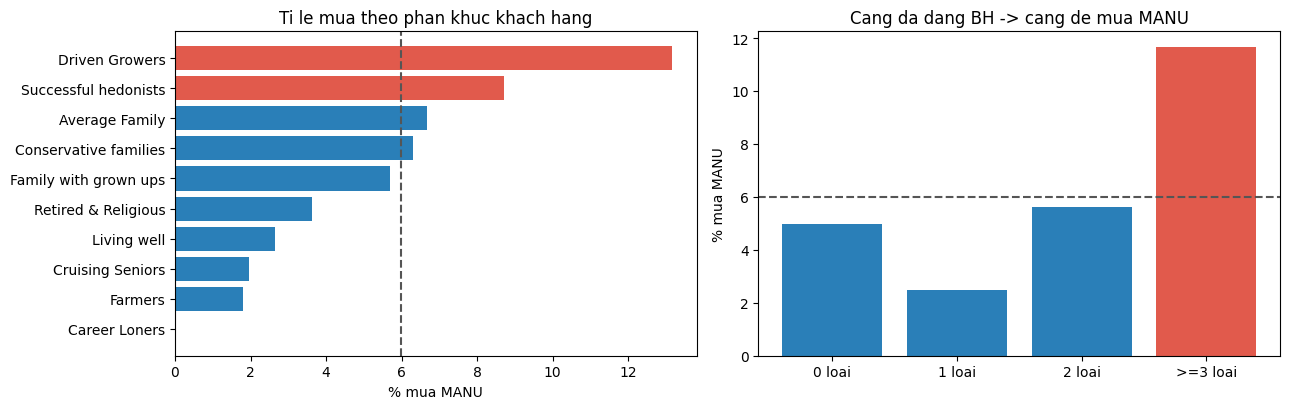

In [4]:
# Bieu do: phan khuc co ten + do da dang
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
gg = g.sort_values('rate')
cols = ['#e15a4c' if r>=BASE*100*1.4 else '#2a7fb8' for r in gg['rate']]
axes[0].barh(gg['ten'], gg['rate'], color=cols)
axes[0].axvline(BASE*100, ls='--', color='#555')
axes[0].set_title('Ti le mua theo phan khuc khach hang'); axes[0].set_xlabel('% mua MANU')
dd = d.reset_index(); dd.columns = ['nhom','n','rate','lift']
cols2 = ['#e15a4c' if r>=BASE*100*1.4 else '#2a7fb8' for r in dd['rate']]
axes[1].bar(dd['nhom'], dd['rate'], color=cols2)
axes[1].axhline(BASE*100, ls='--', color='#555')
axes[1].set_title('Cang da dang BH -> cang de mua MANU'); axes[1].set_ylabel('% mua MANU')
plt.tight_layout(); plt.show()

**Hai phân khúc vàng:** *Driven Growers* (13,1%) và *Successful hedonists* (8,7%) — chỉ ~18% dân số nhưng ~33% người mua. 
**Nên bỏ qua:** *Career Loners* (0%), *Farmers* (1,8%), *Cruising Seniors* (2,0%).

**Độ đa dạng** là tín hiệu hành vi rõ ràng: khách có **≥3 loại bảo hiểm** mua MANU với tỉ lệ **11,7%** (≈2× nền).

## 4 · Vì sao họ mua — đo bằng Information Value (IV)

IV đo sức phân biệt của từng đặc trưng với hành vi mua (quy ước: <0,02 vô dụng · 0,1–0,3 trung bình · >0,3 mạnh). Khớp với thứ hạng SHAP của mô hình LightGBM ở Task 1.

In [5]:
def iv(col):
    s = df[col]
    b = s if s.nunique() <= 45 else pd.qcut(s, 10, duplicates='drop')  # cot ma-hoa danh muc -> moi gia tri 1 bin
    t = df.groupby(b, observed=True)[TARGET].agg(bad='sum', n='size')
    t['good'] = t['n'] - t['bad']
    db = t['bad']/t['bad'].sum(); dg = t['good']/t['good'].sum()
    m = (db>0) & (dg>0)
    return float(((db[m]-dg[m]) * np.log(db[m]/dg[m])).sum())

reasons = [
    ('Da dong phi BH O to (cot 47)',        '47'),
    ('So luong HD BH O to (cot 68)',        '68'),
    ('Da co BH Chay (cot 59)',              '59'),
    ('Phan loai KH chi tiet (cot 1)',       '1'),
    ('Phan khuc khach hang (cot 5)',        '5'),
    ('Thu nhap trung binh khu vuc (cot 42)','42'),
    ('Suc mua khu vuc (cot 43)',            '43'),
]
iv_tbl = pd.DataFrame({'ly_do':[r[0] for r in reasons],
                       'IV':[round(iv(r[1]),3) for r in reasons]}).sort_values('IV', ascending=False)
print(iv_tbl.to_string(index=False))

                               ly_do    IV
        Da dong phi BH O to (cot 47) 0.600
              Da co BH Chay (cot 59) 0.443
        So luong HD BH O to (cot 68) 0.438
       Phan loai KH chi tiet (cot 1) 0.317
        Phan khuc khach hang (cot 5) 0.260
Thu nhap trung binh khu vuc (cot 42) 0.218
            Suc mua khu vuc (cot 43) 0.207


**Dịch sang ngôn ngữ kinh doanh** — mô hình về bản chất xếp hạng theo *"độ giàu hồ sơ bảo hiểm"*:

| # | Tín hiệu | Bằng chứng |
|---|----------|-----------|
| 1 | **Đã đóng phí BH Ô tô** (mạnh nhất) | IV ~0,60 · |SHAP| 0,556 |
| 2 | **Tổng phí bảo hiểm đang đóng cao** | agg_tot_contrib · |SHAP| 0,307 |
| 3 | **Driven Growers / Successful hedonists** | IV 0,26 · woe_1 |SHAP| 0,260 |
| 4 | **Đã có BH Cháy** (nhà, tài sản) | IV 0,43 · |SHAP| 0,154 |
| 5 | **Khu vực thu nhập / sức mua cao** | IV 0,22 / 0,20 |
| 6 | **Sở hữu nhiều loại bảo hiểm** | ≥3 loại → lift 1,95× |

## 5 · Ưu tiên ai trước — segment cho chiến dịch

                              segment  so_KH  so_mua  buy_rate_%  lift
               A · Giau & da bao hiem    508      92        18.1  3.03
              B · Growers / Hedonists   1054     114        10.8  1.81
              C · Chu xe (co BH o to)   2977     276         9.3  1.55
                     Nen (toan bo KH)   5822     348         6.0  1.00
Bo qua: type 4/6/10 hoac suc mua thap   2753     109         4.0  0.66


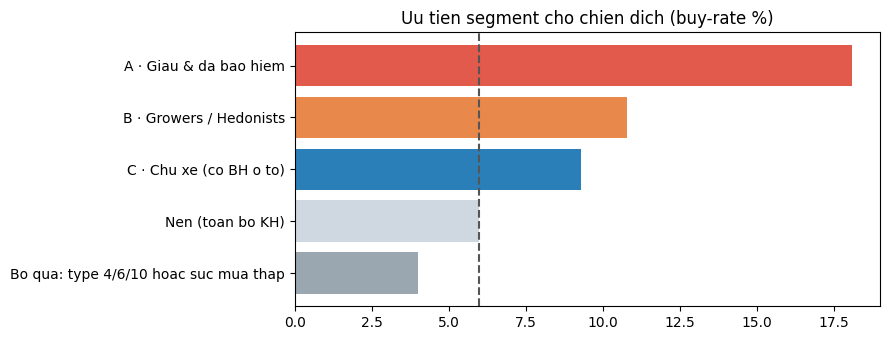

In [6]:
suc_mua_cao = df['43'] >= 6
co_xe       = df['47'] > 0
co_chay     = df['59'] > 0
da_dang     = df['n_types'] >= 3

segdefs = [
    ('A · Giau & da bao hiem',  suc_mua_cao & co_xe & co_chay & da_dang),
    ('B · Growers / Hedonists', df['5'].isin([1,2])),
    ('C · Chu xe (co BH o to)', co_xe),
    ('Nen (toan bo KH)',        pd.Series(True, index=df.index)),
    ('Bo qua: type 4/6/10 hoac suc mua thap', df['5'].isin([4,6,10]) | (df['43']<=3)),
]
seg = pd.DataFrame([{
    'segment':nm, 'so_KH':int(m.sum()), 'so_mua':int(df[TARGET][m].sum()),
    'buy_rate_%':round(df[TARGET][m].mean()*100,1),
    'lift':round(df[TARGET][m].mean()/BASE,2)} for nm,m in segdefs])
print(seg.to_string(index=False))

plt.figure(figsize=(9,3.5))
s2 = seg.iloc[::-1]
colors = ['#e15a4c','#e8884a','#2a7fb8','#cfd8e0','#9aa7b0'][::-1]
plt.barh(s2['segment'], s2['buy_rate_%'], color=colors)
plt.axvline(BASE*100, ls='--', color='#555')
plt.title('Uu tien segment cho chien dich (buy-rate %)'); plt.tight_layout(); plt.show()